(25 pts)

For our first homework assignment, we want you to perform the process of pre-preocessing data to use for training models. This is especially important in a multimodal setting, where you have several modalities that can be extracted from raw data.

Before we start directly processing data, let's think about a project objective or idea that you want to acheive with multimodal modeling/AI. This can range from anything, so be as creative as you want! Here are some questions to answer to help get you started:

1. What goal (or goals) do you want your model to do? An example would be predicting the genre of a movie, or analyzing sentiment from a video. We want you to think about and discuss what is the end goal of the project that you will end up implementing later in the course.

2. List out any datasets that you can find that can help accomplish this. Explain why you think the data is relevant and in addition discuss any drawbacks of the dataset.

3. What modalities do you choose to use? Why? Are there other modalities that could possibly be obtained that you don't plan on using? If so, why?

4. What difficulties did you encounter in obtaining the data?

5. Recall the [six core challenges of multimodal learning](https://arxiv.org/pdf/2209.03430). How do you plan on addressing them in your dataset or anticipate each of them impacting the way you design your dataset?




### Paper Summary

Liang, Zadeh, and Morency (2022) present a taxonomy of multimodal machine learning built on three foundational principles: modalities are heterogeneous (differing in element representation, distribution, structure, information content, noise, and task relevance), connected (sharing statistical, semantic, or causal relationships), and interactive (producing new information when combined for a task). From these principles, the authors derive six core technical challenges -- Representation, Alignment, Reasoning, Generation, Transference, and Quantification -- each broken into subchallenges. The paper surveys historical and recent approaches through this lens, covering methods from early additive fusion to modern large-scale contrastive learning (e.g., CLIP) and Transformer-based architectures, and concludes with open research questions for the field.


### Answers

**1. Goal:** Predict how comfortable a person appears in a video -- binary classification (Comfortable vs. Uncomfortable). This supports human-robot interaction, where a robot needs to sense a person's comfort from facial expressions, tone, and word choice to respond appropriately.

**2. Datasets:**

- **CMU-MOSEI:** 23,500+ video segments from 1,000+ YouTube speakers with sentiment scores (-3 to +3) and emotion labels. We map positive sentiment to "Comfortable" and negative to "Uncomfortable." Drawbacks: videos are opinion monologues (not robot interactions), many are no longer on YouTube (we tried ~30 IDs to get 20 working downloads), and sentiment is a proxy for comfort.
- **CMU-MOSI:** Smaller complementary dataset with similar structure.
- **IEMOCAP:** Dyadic conversations with emotion labels -- closer to interaction but smaller scale.

**3. Modalities:**

- **Visual (video frames):** Facial expressions and body language. Extracted as 64x64 grayscale frames, flattened to 4,096-d vectors.
- **Text (GloVe embeddings):** Word choice reveals sentiment. Pre-extracted 300-d GloVe vectors from the SDK.
- **Acoustic (COVAREP):** Pitch, tone, speaking rate. Available via SDK but skipped for now due to 11 GB file size. Will add in future HWs.
- Not using OpenFace/FACET action units since raw frames already capture facial info.

Per the paper's heterogeneity principle, these three modalities differ across several dimensions: element representation (pixel grids vs. word vectors vs. audio spectrograms), distribution (frame pixel values follow image statistics while word embeddings follow Zipf-like distributions), structure (spatial for images, sequential for text, temporal for audio), and information content (visual captures appearance while text captures semantic meaning). This heterogeneity is exactly what motivates multimodal fusion -- each modality contributes unique, complementary information.

**4. Difficulties:**

- SDK server has intermittent availability; many download links reported broken in 2025.
- ~25% of YouTube videos deleted or corrupted since the 2018 dataset release.
- Full feature files are very large (COVAREP ~11 GB), requiring selective downloads.
- SDK's `setup.py` uses deprecated APIs, needing manual workarounds to install.

**5. Six core challenges (Liang et al., 2022) applied to our project:**

1. **Representation** (learning representations that reflect cross-modal interactions): Our modalities live in very different feature spaces -- 4,096-d pixel vectors, 300-d GloVe embeddings, and (eventually) COVAREP acoustic features. The paper identifies three subchallenges: fusion (combining modalities into a joint representation), coordination (aligning separate representations via shared constraints like CCA or contrastive learning), and fission (factorizing into modality-specific and shared factors). We plan to start with representation fusion using additive or attention-based approaches, and later explore coordination (e.g., contrastive learning between visual and text embeddings) and fission (separating modality-specific from shared sentiment information).

2. **Alignment** (identifying connections between modality elements): Video frames run at 30fps while text features are at the word level and audio at fixed time intervals. The paper distinguishes discrete alignment (matching discrete elements like words to image regions), continuous alignment (warping continuous signals with ambiguous segmentation), and contextualized representations (learning alignment implicitly through cross-attention). We rely on the CMU-MOSEI SDK's timestamp alignment, which provides discrete segment-level alignment. For future work, cross-modal attention (a contextualized representation approach) could learn finer alignment between individual frames and words.

3. **Reasoning** (composing knowledge through multiple inferential steps): Detecting comfort requires combining evidence across modalities -- a person might smile (visual) while saying something negative (text), as in sarcasm. The paper breaks reasoning into structure modeling, intermediate concepts, inference paradigms, and external knowledge. Our task involves temporal structure (comfort varies over time within a video) and potentially interactive reasoning (facial expressions must be interpreted in context of what is being said). We plan to use attention-based intermediate concepts to let the model learn which modality to weight at each moment, and explore hierarchical structure to compose frame-level predictions into video-level comfort scores.

4. **Generation** (producing raw modalities reflecting cross-modal coherence): This challenge is not central to our classification task. However, the paper's summarization subchallenge is relevant -- we are effectively summarizing each video into a single comfort label. The paper's translation subchallenge (mapping one modality to another while preserving semantics) could also apply if we extend to generating textual explanations of comfort predictions.

5. **Transference** (transferring knowledge between modalities): We already leverage this through pre-trained features -- GloVe embeddings transfer knowledge from large text corpora, and COVAREP transfers acoustic engineering knowledge. The paper identifies cross-modal transfer (fine-tuning models from one modality to another), co-learning (sharing representations across modalities during training), and model induction (separate models that pseudo-label for each other). We plan to use co-learning by training a joint model where text and audio features help the visual branch learn better comfort representations, even when visual signal alone is ambiguous. The paper also describes co-learning via generation, where translating from one modality to another as an auxiliary task enriches the primary modality's representations -- we could add an auxiliary task of predicting visual features from text to force the model to learn cross-modal correspondences.

6. **Quantification** (empirical and theoretical understanding of multimodal learning): The paper highlights subchallenges of understanding heterogeneity dimensions, interconnections, and learning dynamics. We plan to perform ablation studies (removing one modality at a time) to quantify each modality's contribution, following the paper's discussion of feature attribution methods like Shapley values and EMAP. We will also track whether the model exhibits modality bias (e.g., ignoring visual features and relying solely on text), which the paper identifies as a key risk in multimodal systems.


(20 pts)

We have provided a skeleton for you to start coding with, which contains an example of extracting frames of a video as images. Feel free to use this code as a starting point, but you are free to and encouraged to add more! The goal of this assignment (and what you will be graded on), is to extract a set of modalities from the dataset of your choice that is rich (in the sense that it would make sense to use/has valuable information) and contains unique information from other modalities.

**We strongly encourage that you take a good amount of time exploring and choosing the dataset you want to go with. The dataset/domain you decide to go with and the modalities you choose will be used for the rest of the HWs in this class. Create your dataset with this in mind!**

**You will submit a copy of this notebook with the code alongside your writeup. In your writeup, discuss the following:**


What difficulties did you encounter in extracting the modalities?  


### Difficulties in Extracting Modalities

- **Video availability:** Many CMU-MOSEI YouTube videos have been deleted since 2018. In our sample, a significant fraction of attempted IDs were unavailable or corrupt, requiring us to iterate through IDs to build a usable set.
- **Frame volume:** Even at 1 fps sampling, 20 videos produce thousands of frames. Full-dataset scale (~1M frames) would need batched processing and careful memory management.
- **Resolution trade-off:** Downsampling to 64x64 grayscale keeps features manageable (4,096-d) but loses color and fine detail.
- **Cross-modal alignment:** Frames are at 30fps while text is word-level. We relied on the SDK's timestamp alignment and HDF5 interval data.
- **Text averaging:** Averaging all GloVe word vectors per video into one 300-d vector loses word order, but is a simple video-level representation.

In [1]:
!pip install opencv-python numpy pandas matplotlib seaborn scikit-learn h5py tqdm yt-dlp

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
import cv2
import os

video_path = "/home/farandhigh-ubuntu/Documents/mmai/hw1/cmumosei_videos/-aqamKhZ1Ec.mp4"  # CMU-MOSEI sample video
output_dir = "/home/farandhigh-ubuntu/Documents/mmai/hw1/cmumosei_frames/-aqamKhZ1Ec"  # Output directory for frames

os.makedirs(output_dir, exist_ok=True)

cap = cv2.VideoCapture(video_path)

if cap.isOpened():
    frame_count = 0

    while True:
      ret, frame = cap.read()

      if not ret:
        break

      frame_filename = os.path.join(output_dir, f'frame_{frame_count:05d}.jpg')
      cv2.imwrite(frame_filename, frame)
      #print(f'Extracted {frame_filename}')

      frame_count += 1

    cap.release()
    print(f"Completed extracting frames to {output_dir}")

Completed extracting frames to /home/farandhigh-ubuntu/Documents/mmai/hw1/cmumosei_frames/-aqamKhZ1Ec


In [3]:
# Extended processing: extract frames from ALL CMU-MOSEI videos, map labels, load text modality
# Building on the single-video extraction above, we now process the full sample set.

import h5py
import numpy as np
import glob

DATA_DIR   = "/home/farandhigh-ubuntu/Documents/mmai/hw1/cmumosei_data"
VIDEO_DIR  = "/home/farandhigh-ubuntu/Documents/mmai/hw1/cmumosei_videos"
FRAME_DIR  = "/home/farandhigh-ubuntu/Documents/mmai/hw1/cmumosei_frames"
LABELS_FILE = os.path.join(DATA_DIR, "CMU_MOSEI_Labels.csd")

# --- Load labels and map sentiment to Comfortable / Uncomfortable ---
video_label_map = {}
with h5py.File(LABELS_FILE, 'r') as f:
    data = f['All Labels']['data']
    for vid_file in glob.glob(os.path.join(VIDEO_DIR, "*.mp4")):
        if os.path.getsize(vid_file) < 100 * 1024:  # skip corrupt stubs < 100KB
            continue
        vid_id = os.path.splitext(os.path.basename(vid_file))[0]
        if vid_id in data:
            features = data[vid_id]['features'][:]
            avg_sentiment = np.mean(features[:, 0])  # column 0 = sentiment score
            label = "Comfortable" if avg_sentiment >= 0 else "Uncomfortable"  # neutral-or-positive = Comfortable
            video_label_map[vid_id] = {
                "sentiment": float(avg_sentiment),
                "label": label,
                "path": vid_file
            }
            print(f"  {vid_id}: sentiment={avg_sentiment:.3f} -> {label}")

print(f"\nTotal videos with labels: {len(video_label_map)}")

# --- Extract frames from all videos (every 30th frame, resized to 64x64 grayscale) ---
FRAME_SAMPLE_RATE = 30
IMG_SIZE = (64, 64)

all_frames = []
all_labels = []

for vid_id, info in video_label_map.items():
    vid_frame_dir = os.path.join(FRAME_DIR, vid_id)
    os.makedirs(vid_frame_dir, exist_ok=True)

    cap = cv2.VideoCapture(info["path"])
    if not cap.isOpened():
        continue

    frame_count = 0
    extracted = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if frame_count % FRAME_SAMPLE_RATE == 0:
            frame_resized = cv2.resize(frame, IMG_SIZE)
            frame_gray = cv2.cvtColor(frame_resized, cv2.COLOR_BGR2GRAY)
            cv2.imwrite(os.path.join(vid_frame_dir, f'frame_{frame_count:05d}.jpg'), frame_gray)
            all_frames.append(frame_gray.flatten().astype(np.float32) / 255.0)
            all_labels.append(info["label"])
            extracted += 1
        frame_count += 1

    cap.release()
    print(f"Video {vid_id} ({info['label']}): {frame_count} total frames, {extracted} extracted")

all_frames = np.array(all_frames)
all_labels = np.array(all_labels)
print(f"\nFrame features: {all_frames.shape}  |  Comfortable: {np.sum(all_labels=='Comfortable')}  |  Uncomfortable: {np.sum(all_labels=='Uncomfortable')}")

# --- Load text modality (GloVe word vectors) ---
GLOVE_FILE = os.path.join(DATA_DIR, "CMU_MOSEI_TimestampedWordVectors.csd")
text_features_by_video = {}
with h5py.File(GLOVE_FILE, 'r') as f:
    glove_data = f['glove_vectors']['data']
    for vid_id in video_label_map.keys():
        if vid_id in glove_data:
            feats = glove_data[vid_id]['features'][:]
            text_features_by_video[vid_id] = np.mean(feats, axis=0)

print(f"Text features loaded for {len(text_features_by_video)} videos (GloVe 300-d)")

  18JTkk8JbeU: sentiment=0.000 -> Comfortable
  -VmheDA92mM: sentiment=-1.067 -> Uncomfortable
  CBYQDIqucxE: sentiment=1.000 -> Comfortable
  R-17BoOk4kc: sentiment=2.333 -> Comfortable
  Oa2xVjzAMFc: sentiment=0.611 -> Comfortable
  qBanrqkzobg: sentiment=1.333 -> Comfortable
  9-EO2oCAGA4: sentiment=0.333 -> Comfortable
  0EAAfLCQabY: sentiment=-0.556 -> Uncomfortable
  faXGVcVcVsE: sentiment=0.771 -> Comfortable
  xsiHAO0gq74: sentiment=1.000 -> Comfortable
  pAclBdj20ZU: sentiment=0.750 -> Comfortable
  eJfT7-dDqzA: sentiment=0.667 -> Comfortable
  JF-5nlUNx_g: sentiment=0.812 -> Comfortable
  zjYEBwXGD8I: sentiment=0.556 -> Comfortable
  0eTibWQdO5M: sentiment=-0.667 -> Uncomfortable
  Cd0JH1AreDw: sentiment=-0.167 -> Uncomfortable
  -9y-fZ3swSY: sentiment=0.708 -> Comfortable
  l1jW3OMXUzs: sentiment=-1.333 -> Uncomfortable
  aE7sckIAWuw: sentiment=-0.889 -> Uncomfortable
  0vXaXWx7Rvo: sentiment=0.944 -> Comfortable
  G8p4QMjLUXI: sentiment=0.630 -> Comfortable
  VzDXgBOe5iI: s

Video 18JTkk8JbeU (Comfortable): 2478 total frames, 83 extracted


Video -VmheDA92mM (Uncomfortable): 14911 total frames, 498 extracted
Video CBYQDIqucxE (Comfortable): 812 total frames, 28 extracted


Video R-17BoOk4kc (Comfortable): 5972 total frames, 200 extracted


Video Oa2xVjzAMFc (Comfortable): 1843 total frames, 62 extracted


...

Video G8p4QMjLUXI (Comfortable): 8095 total frames, 270 extracted


Video VzDXgBOe5iI (Comfortable): 1953 total frames, 66 extracted
Video -aqamKhZ1Ec (Uncomfortable): 1260 total frames, 42 extracted


Video tvE_DucE0_k (Comfortable): 2224 total frames, 75 extracted


Video -3g5yACwYnA (Comfortable): 3473 total frames, 116 extracted


Video P0WaXnH37uI (Comfortable): 19020 total frames, 634 extracted

Frame features: (8111, 4096)  |  Comfortable: 4529  |  Uncomfortable: 3582
Text features loaded for 26 videos (GloVe 300-d)


(15 pts)

As part of this assignment, we will look into visualizing you dataset in three parts:

1. Visualizing Data Distribution
2. Viualizing Samples
3. Visualizing Input Distribution

We have provided scripts that these visualizations using [t-SNE](https://en.wikipedia.org/wiki/T-distributed_stochastic_neighbor_embedding) (t-distributed stochastic neighbor embedding). Your goal is to use these to visualize each of these for your dataset and include the visualziations in your submission. You will likely need to adjust the hyperparameters for the tsne model.

**Modify the functions to try different ways to visualize the dataset. Use differenrt distributions, visualizations, etc. Be creative! In the write up, discuss what visualizations you tried, why, and submit what the visualizations looked like.**

In [4]:
# Packages (feel free to include more if needed)!
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.manifold import TSNE
from sklearn.datasets import make_blobs
from collections import Counter

# Data Distribution

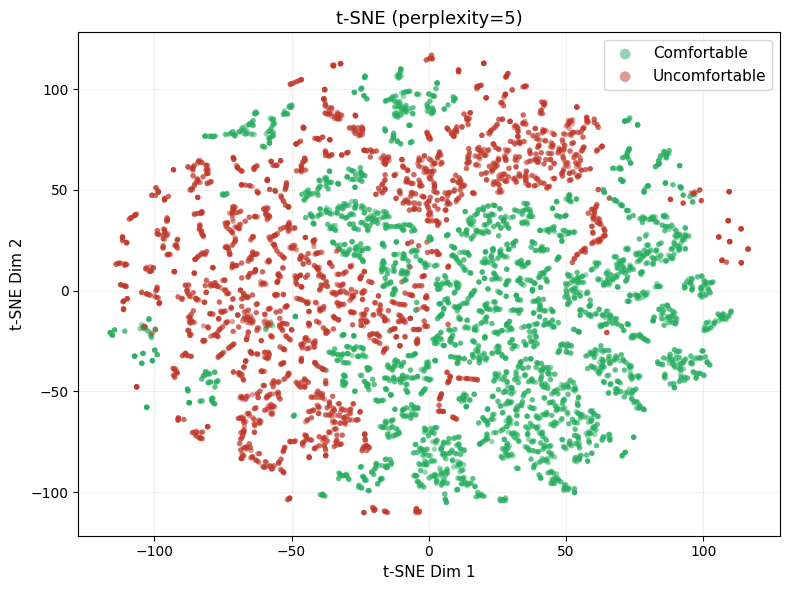

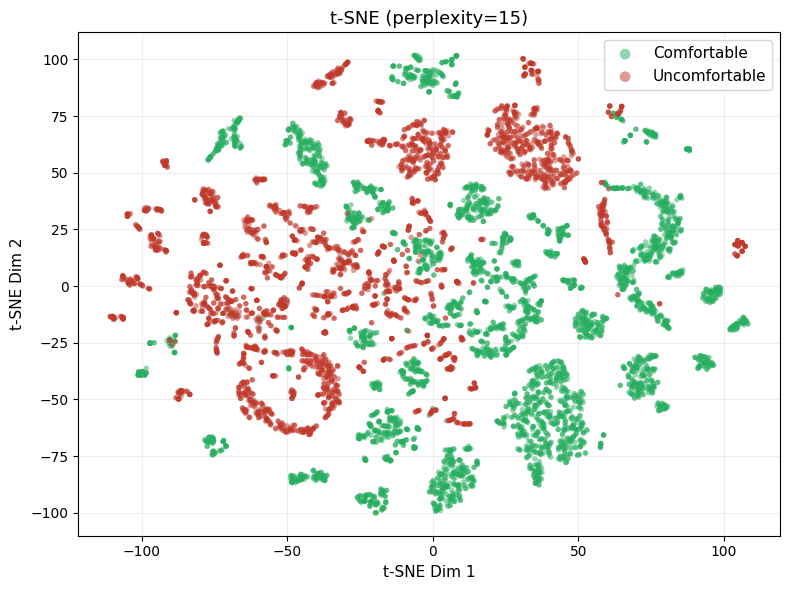

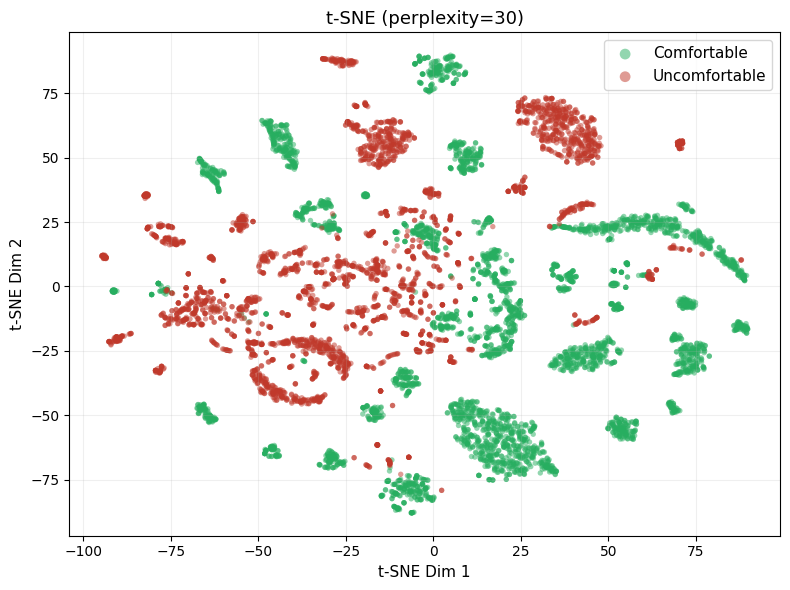

In [5]:
def visualize_data_distribution(data, labels=None, x_feature = "X_Placeholder", y_feature = "Y_placeholder", num_components = 2,
                                perplexity = 30, num_iterations = 1000):
  """
  Visualizes the distribution of a specified feature in a DataFrame.

  Args:
      data (np.array): The dataset that you plan on using as a 2D representation.
      labels (np.array): Optional class labels for color-coding points.
  """
  perplexity = min(perplexity, len(data) - 1)
  tsne = TSNE(n_components = num_components, perplexity = perplexity, max_iter = num_iterations, random_state=42)
  tsne_data = tsne.fit_transform(data)

  plt.figure(figsize=(8, 6))

  if labels is not None:
      colors = {'Comfortable': '#27ae60', 'Uncomfortable': '#c0392b'}
      for lbl in np.unique(labels):
          mask = labels == lbl
          plt.scatter(tsne_data[mask, 0], tsne_data[mask, 1],
                      label=lbl, alpha=0.5, s=15, color=colors.get(lbl, None), edgecolors='none')
      plt.legend(fontsize=11, markerscale=2)
  else:
      sns.histplot(x=tsne_data[:, 0], y=tsne_data[:, 1], bins=30)

  plt.title(f't-SNE (perplexity={perplexity})', fontsize=13)
  plt.xlabel(x_feature, fontsize=11)
  plt.ylabel(y_feature, fontsize=11)
  plt.grid(True, alpha=0.2)
  plt.tight_layout()
  plt.show()
  return tsne_data

# Compare perplexity values: low (local structure), medium, high (global structure)
for perp in [5, 15, 30]:
    tsne_result = visualize_data_distribution(all_frames, labels=all_labels,
                                              x_feature="t-SNE Dim 1", y_feature="t-SNE Dim 2",
                                              perplexity=perp)



# Samples

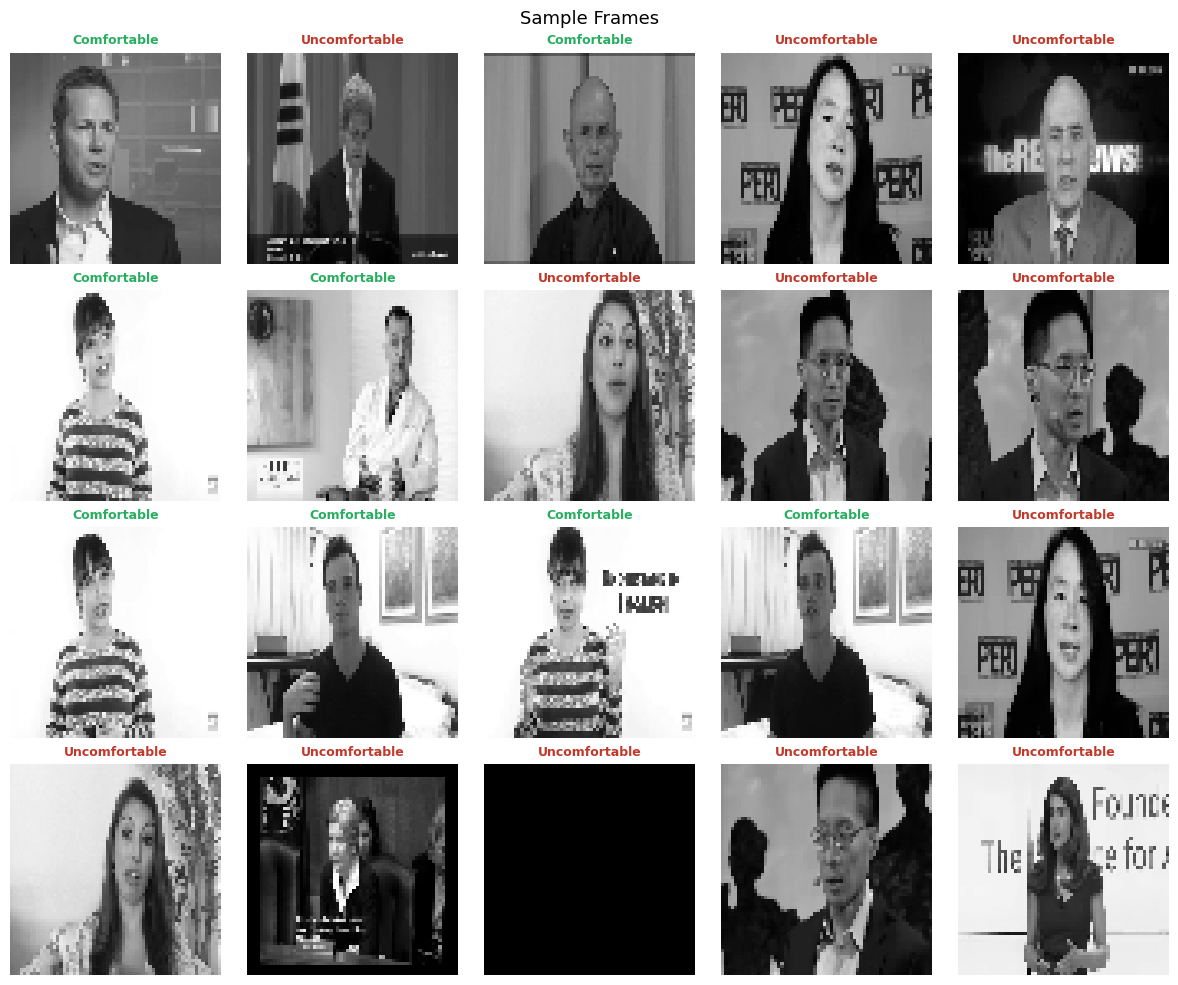

In [6]:
def visualize_samples(data, labels=None, num_samples = 10):
  """
  Visualizes samples from the dataset by showing actual frame images in a grid.

  Args:
      data (np.array): The dataset that you plan on using as a 2D representation.
      labels (np.array): Optional class labels for color-coding.
      num_samples (int): The number of samples to visualize.
  """

  if num_samples > len(data):
    print(f"Error: Number of samples ({num_samples}) exceeds the dataset size ({len(data)}).")
    num_samples = len(data)

  random_indices = np.random.choice(len(data), size = num_samples, replace = False)

  # Show actual frame images in a grid
  n_show = min(20, num_samples)
  cols = 5
  rows = (n_show + cols - 1) // cols
  fig, axes = plt.subplots(rows, cols, figsize=(12, 2.5 * rows))
  axes = axes.flatten()
  for i in range(n_show):
      idx = random_indices[i]
      img = data[idx].reshape(IMG_SIZE)
      lbl = labels[idx] if labels is not None else ""
      color = '#27ae60' if lbl == 'Comfortable' else '#c0392b'
      axes[i].imshow(img, cmap='gray', vmin=0, vmax=1)
      axes[i].set_title(lbl, fontsize=9, color=color, fontweight='bold')
      axes[i].axis('off')
  for j in range(n_show, len(axes)):
      axes[j].axis('off')
  plt.suptitle("Sample Frames", fontsize=13)
  plt.tight_layout()
  plt.show()

# Visualize a random subset
np.random.seed(42)
visualize_samples(all_frames, labels=all_labels, num_samples=50)


# Input Distribution

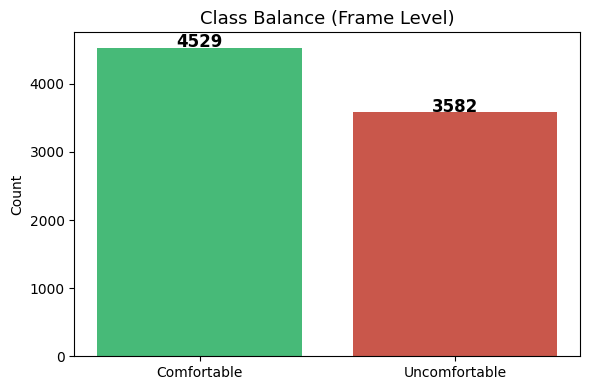

In [7]:
def visualize_input_distribution(data, labels=None):
  """
  Visualizes input_distribution from the dataset.

  Args:
      data (np.array): The dataset that you plan on using as a 2D representation.
      labels (np.array): Optional class labels for color-coding.
  """
  if labels is not None:
      counts = Counter(labels)
      colors_bar = ['#27ae60' if k == 'Comfortable' else '#c0392b' for k in counts.keys()]

      fig, ax = plt.subplots(figsize=(6, 4))
      bars = ax.bar(counts.keys(), counts.values(), color=colors_bar, alpha=0.85)
      for bar, ct in zip(bars, counts.values()):
          ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                  str(ct), ha='center', fontsize=12, fontweight='bold')
      ax.set_title("Class Balance (Frame Level)", fontsize=13)
      ax.set_ylabel("Count")
      plt.tight_layout()
      plt.show()

# Visualize the input distribution
visualize_input_distribution(all_frames, labels=all_labels)


### Visualization Discussion

**t-SNE with varying perplexity (5, 15, 30):**

- Perplexity=5: Tight, fragmented clusters where each video forms its own island. Emphasizes local structure.
- Perplexity=15: Clusters begin to merge, revealing intermediate groupings between individual videos.
- Perplexity=30: Balanced view. Clusters group by video identity but some class-level separation appears.

**Sample frame grid:** Frames across classes look visually similar (people talking to cameras), confirming raw pixels alone are weak for this task.

**Class balance:** At the video level the split is skewed (19 Comfortable vs. 8 Uncomfortable, ~70/30), but at the frame level it is more balanced (~56/44) because Uncomfortable videos tend to be longer.

**Key takeaway:** t-SNE clusters reflect speaker identity, not sentiment. This motivates using higher-level features (GloVe, COVAREP) and multimodal fusion rather than raw pixels.


(20 pts)

Now let's consider what evaluation metrics you would want to use in training and validation. Answer the following:

1. What evalution metrics are you planning on using? Why?
2. Are there any other metrics that could be used here or that you considered?
3. List out the pros and cons of the evaluation metrics you decided to go with.

In addition, code up functions that calculate the metric. We have provided a template to start with. This will be used later for when we do start training models, so take some time in designing this!

In [8]:
# Accuracy as an example
def evaluation_metric(predictions, ground_truths):
  num_correct = 0
  num_tot = 0

  for prediction, truth in zip(predictions, ground_truths):
    if prediction == truth:
      num_correct += 1
    num_tot += 1

  if num_tot == 0:
    raise ValueError("Issue reading ground truths/No ground truths provided!")

  return num_correct / num_tot

# Additional metrics for binary classification (Comfortable vs Uncomfortable)

def precision_metric(predictions, ground_truths, positive_class="Comfortable"):
  """Precision: TP / (TP + FP)."""
  tp = sum(1 for p, g in zip(predictions, ground_truths) if p == positive_class and g == positive_class)
  fp = sum(1 for p, g in zip(predictions, ground_truths) if p == positive_class and g != positive_class)
  return tp / (tp + fp) if (tp + fp) > 0 else 0.0

def recall_metric(predictions, ground_truths, positive_class="Comfortable"):
  """Recall: TP / (TP + FN)."""
  tp = sum(1 for p, g in zip(predictions, ground_truths) if p == positive_class and g == positive_class)
  fn = sum(1 for p, g in zip(predictions, ground_truths) if p != positive_class and g == positive_class)
  return tp / (tp + fn) if (tp + fn) > 0 else 0.0

def f1_metric(predictions, ground_truths, positive_class="Comfortable"):
  """F1 Score: harmonic mean of precision and recall."""
  p = precision_metric(predictions, ground_truths, positive_class)
  r = recall_metric(predictions, ground_truths, positive_class)
  return 2 * (p * r) / (p + r) if (p + r) > 0 else 0.0

# Demo with a random baseline
np.random.seed(0)
dummy_predictions = np.random.choice(["Comfortable", "Uncomfortable"], size=len(all_labels))

print("Random Baseline:")
print(f"  Accuracy:  {evaluation_metric(dummy_predictions, all_labels):.4f}")
print(f"  Precision: {precision_metric(dummy_predictions, all_labels):.4f}")
print(f"  Recall:    {recall_metric(dummy_predictions, all_labels):.4f}")
print(f"  F1 Score:  {f1_metric(dummy_predictions, all_labels):.4f}")

print("\nPerfect Classifier:")
print(f"  Accuracy:  {evaluation_metric(all_labels, all_labels):.4f}")


Random Baseline:
  Accuracy:  0.4980
  Precision: 0.5570
  Recall:    0.4928
  F1 Score:  0.5230

Perfect Classifier:
  Accuracy:  1.0000


### Evaluation Metric Answers

**1. Planned metrics:** Accuracy, Precision, Recall, and F1 Score.

- Accuracy: Overall correctness.
- Precision: How reliable "Comfortable" predictions are (matters if a robot shouldn't wrongly assume comfort).
- Recall: How many truly comfortable people we catch (matters if missing discomfort is costly).
- F1: Balances precision and recall -- important given our ~56/44 class split.

**2. Other metrics considered:** AUC-ROC (needs confidence scores, not hard labels), Matthews Correlation Coefficient (better for imbalanced data), MAE on raw sentiment scores (treats it as regression), and Weighted F1.

**3. Pros and cons:**

| Metric | Pros | Cons |
|--------|------|------|
| Accuracy | Simple, intuitive | Can be misleading with imbalanced classes |
| Precision | Controls false positives | Ignores false negatives |
| Recall | Controls false negatives | Ignores false positives |
| F1 | Balances both | Doesn't account for true negatives |

(15 pts)

For the next part of this assignment, we are going to play around with instruction tuning. Instruction tuning is creating a prompt that you would feed to a model in order to have it complete a certain assignment by constraing what it can output without the need to train. This is when you prompt the model in specifc ways to guarentee a specific output (e.g. one-word labels, value ranges or classifications). Provide prompts that would be able to guarentee the right output based on the data. **Just provide the prompts, you don't need to train the model.**

Scenario 1: You have a dataset of reviews from restaurants, when you see this review:
"This place stinks, the service was awful and the food was not cooked. I will never come back here!"
Provide a prompt that would have the model return the sentiment of the review, which is negative.

Scenario 2: You are looking through a dataset of angry, sad, and happy faces. Provide a prompt that would get the emotion a person is expressing.

Scenario 3: A dataset of novels, with the following paragraph:
"The man, Edgar, flew to Italy to hike the Alps. He was looking forward to going skiing there."

Provide prompts to get the name of the subject, where they are going, and what they were planning to do.

### Instruction Tuning Prompts

**Scenario 1 (Restaurant review sentiment):**

> You are a sentiment classifier. Read the following restaurant review and respond with exactly one word: "positive", "negative", or "neutral".
>
> Review: "This place stinks, the service was awful and the food was not cooked. I will never come back here!"
>
> Sentiment:

Expected output: **negative**

**Scenario 2 (Facial emotion classification):**

> You are an emotion recognition system. Look at the image of a person's face and classify the emotion being expressed. Respond with exactly one of the following labels: "angry", "sad", or "happy". Do not include any other text.
>
> Emotion:

Expected output: one of **angry**, **sad**, or **happy**

**Scenario 3 (Named entity and intent extraction from a novel):**

Prompt for the subject's name:
> Extract only the name of the main subject from the following paragraph. Respond with just the name, nothing else.
>
> "The man, Edgar, flew to Italy to hike the Alps. He was looking forward to going skiing there."
>
> Name:

Expected output: **Edgar**

Prompt for the destination:
> Where is the subject traveling to in the following paragraph? Respond with only the country or location name.
>
> "The man, Edgar, flew to Italy to hike the Alps. He was looking forward to going skiing there."
>
> Destination:

Expected output: **Italy**

Prompt for the planned activity:
> What activities was the subject planning to do in the following paragraph? Respond with a short comma-separated list of activities only.
>
> "The man, Edgar, flew to Italy to hike the Alps. He was looking forward to going skiing there."
>
> Activities:

Expected output: **hike, skiing**

**As a bonus part of this assignment (10 points of extra credit)**, we welcome you to do the following: Create a project where you create a dataset (separate from the one you will be using for the rest of the HWs) and train some models on the dataset. For the bonus credit, explain what goal you went with, the model you decided to use, and the evalutaion metrics used. Explain your reasoning for each of the choices. Be as creative as possible!

Here is what we are looking for:

* What is the task you are looking to do
* What dataset you are using
* The modalities you will extract
* What model you will be using
* The evaluation metrics you employ
* Results from training adn testing using the evaluation metrics

Be sure to provide a rationale for each design choice!



In [9]:
# BONUS CODE HERE


(5 pts)

Now, let's take some time to reflect. We have dug deep into the data collection and process portion of machine learning. Take some time to discuss:

1. The most interesting topic discussed in this homework assignment.
2. A challenging aspect that you did not expect to deal with and what insights you used to address it.
3. How you feel about the overall quality of your dataset? Is there anything lacking? What is particularly great about it?

There is no specific right answer we are looking for, answer how you think!

### Reflection

**1. Most interesting topic:** Seeing t-SNE clusters organize by speaker identity rather than sentiment. Raw pixels capture lighting and background, not comfort level -- a clear motivation for why multimodal learning and higher-level features matter.

**2. Unexpected challenge:** The number of unavailable YouTube videos. The dataset is from 2018, and many videos are now deleted. We tried ~30 IDs to get 20 working videos, and leaned on pre-extracted SDK features as a more stable alternative to raw video.

**3. Dataset quality:** Strong multimodal richness (text, audio, visual for the same segments) and standardized labels. Weakness: it's YouTube monologues, not human-robot interactions, so the sentiment-to-comfort mapping is a proxy. The class balance (~56/44) is reasonable with our expanded 26-video sample.

In [10]:
# Summary
print(f"Visual modality:  {all_frames.shape[0]} frames, {all_frames.shape[1]}-dim feature vectors")
print(f"Text modality:    {len(text_features_by_video)} videos, 300-dim GloVe embeddings")
print(f"Labels:           Comfortable={np.sum(all_labels=='Comfortable')}, Uncomfortable={np.sum(all_labels=='Uncomfortable')}")

Visual modality:  8111 frames, 4096-dim feature vectors
Text modality:    26 videos, 300-dim GloVe embeddings
Labels:           Comfortable=4529, Uncomfortable=3582
